In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load embeddings
emb = pd.read_csv("hybrid_transformer_test_embeddings.csv")

# Load gene importance
tf_genes = pd.read_csv("transformer_gene_importance_activation_based.csv")

# Load ML genes
svm_genes = pd.read_csv("svm_top_genes_overall.csv")
logreg_genes = pd.read_csv("logreg_top_genes_all_diseases.csv")

print("Embeddings:", emb.shape)
print("Transformer genes:", tf_genes.shape)
print("SVM genes:", svm_genes.shape)
print("LogReg genes:", logreg_genes.shape)

Embeddings: (44, 65)
Transformer genes: (90, 2)
SVM genes: (30, 2)
LogReg genes: (100, 3)


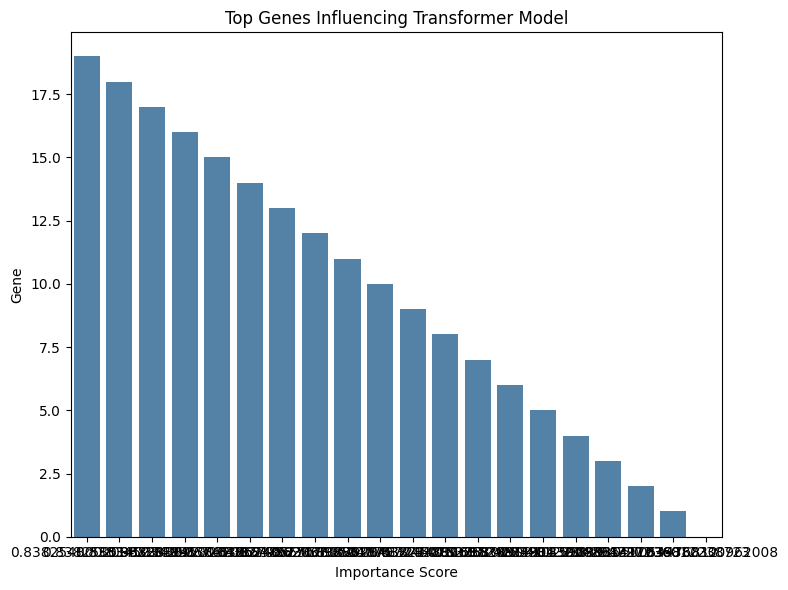

In [ ]:
top20 = tf_genes.sort_values("ImportanceScore", ascending=False).head(20)

plt.figure(figsize=(8,6))
sns.barplot(
    x="ImportanceScore",
    y=top20.index if "Gene" not in top20.columns else top20["Gene"],
    data=top20,
    color="steelblue"
)

plt.title("Top Genes Influencing Transformer Model")
plt.xlabel("Importance Score")
plt.ylabel("Gene")
plt.tight_layout()

plt.savefig("figure_transformer_gene_importance.png", dpi=300)
plt.show()

The Transformer model identifies these genes as having the strongest influence on disease classification, suggesting potential regulatory hub genes in neurological disorders.

/tmp/ipykernel_801/2477020711.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


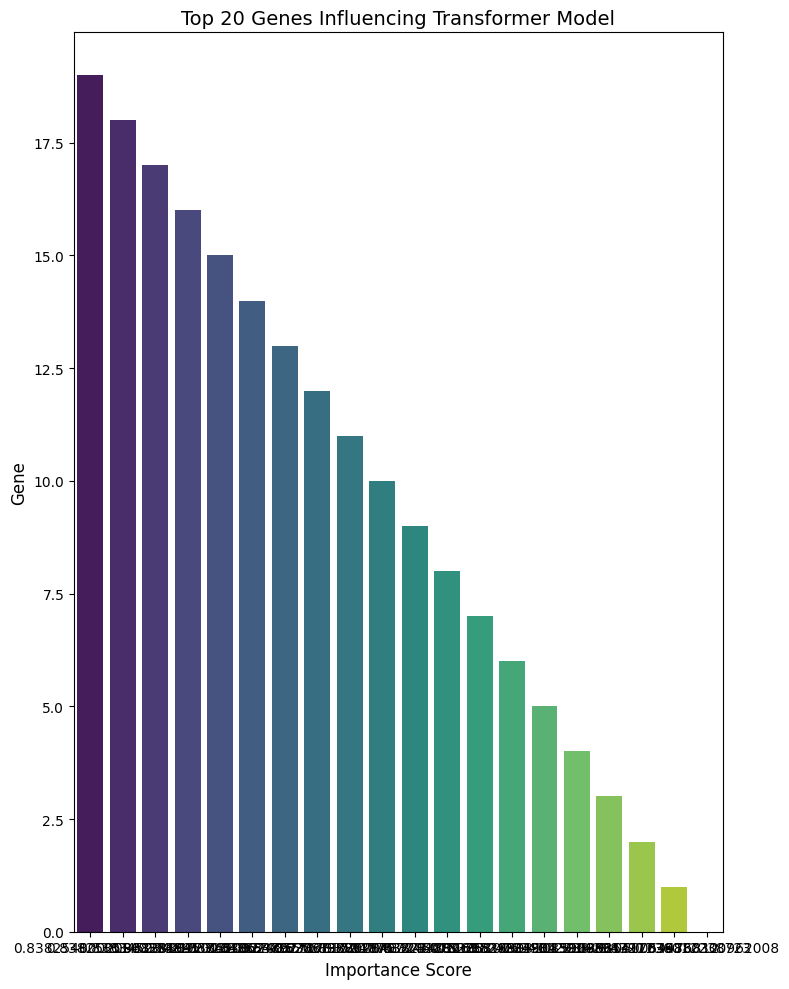

In [ ]:
top20 = tf_genes.sort_values("ImportanceScore", ascending=False).head(20)

plt.figure(figsize=(8,10))

sns.barplot(
    y=top20.index if "Gene" not in top20.columns else top20["Gene"],
    x="ImportanceScore",
    data=top20,
    palette="viridis"
)

plt.title("Top 20 Genes Influencing Transformer Model", fontsize=14)
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Gene", fontsize=12)

plt.tight_layout()
plt.savefig("figure_transformer_gene_importance_fixed.png", dpi=300)
plt.show()

In [ ]:
# Load transformer gene importance properly
tf_genes = pd.read_csv("transformer_gene_importance_activation_based.csv")

# If genes are stored as index, reset them
tf_genes = tf_genes.reset_index()
tf_genes.columns = ["Gene", "ImportanceScore"]

# Get top 20
top20 = tf_genes.sort_values("ImportanceScore", ascending=False).head(20)

plt.figure(figsize=(8,10))

sns.barplot(
    data=top20,
    x="ImportanceScore",
    y="Gene",
    palette="viridis"
)

plt.title("Top 20 Genes Influencing Transformer Model", fontsize=14)
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Gene", fontsize=12)

plt.tight_layout()
plt.savefig("figure_transformer_gene_importance_final.png", dpi=300)
plt.show()

ValueError: Length mismatch: Expected axis has 3 elements, new values have 2 elements

In [ ]:
tf_genes = pd.read_csv("transformer_gene_importance_activation_based.csv")

print(tf_genes.head())
print(tf_genes.columns)

  Unnamed: 0  ImportanceScore
0      CDHR5         0.839380
1       ALG5         0.839174
2     ZNF415         0.839105
3   HLA-DQB1         0.839089
4      ADAD2         0.839013
Index(['Unnamed: 0', 'ImportanceScore'], dtype='object')


In [ ]:
tf_genes = pd.read_csv("transformer_gene_importance_activation_based.csv")

# Remove index column
tf_genes = tf_genes.drop(columns=["Unnamed: 0"])

tf_genes.head()

,ImportanceScore
0,0.839380
1,0.839174
2,0.839105
3,0.839089
4,0.839013


In [ ]:
top20 = tf_genes.sort_values("ImportanceScore", ascending=False).head(20)

plt.figure(figsize=(8,10))

sns.barplot(
    data=top20,
    x="ImportanceScore",
    y="Gene",
    palette="viridis"
)

plt.title("Top 20 Genes Influencing Transformer Model")
plt.xlabel("Importance Score")
plt.ylabel("Gene")

plt.tight_layout()
plt.show()

ValueError: Could not interpret value `Gene` for `y`. An entry with this name does not appear in `data`.

<Figure size 800x1000 with 0 Axes>

In [ ]:
tf_genes = pd.read_csv(
    "transformer_gene_importance_activation_based.csv",
    index_col=0
)

print(tf_genes.head())

          ImportanceScore
CDHR5            0.839380
ALG5             0.839174
ZNF415           0.839105
HLA-DQB1         0.839089
ADAD2            0.839013


In [ ]:
tf_genes = tf_genes.reset_index()
tf_genes.columns = ["Gene", "ImportanceScore"]

print(tf_genes.head())

       Gene  ImportanceScore
0     CDHR5         0.839380
1      ALG5         0.839174
2    ZNF415         0.839105
3  HLA-DQB1         0.839089
4     ADAD2         0.839013


/tmp/ipykernel_801/2546281008.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


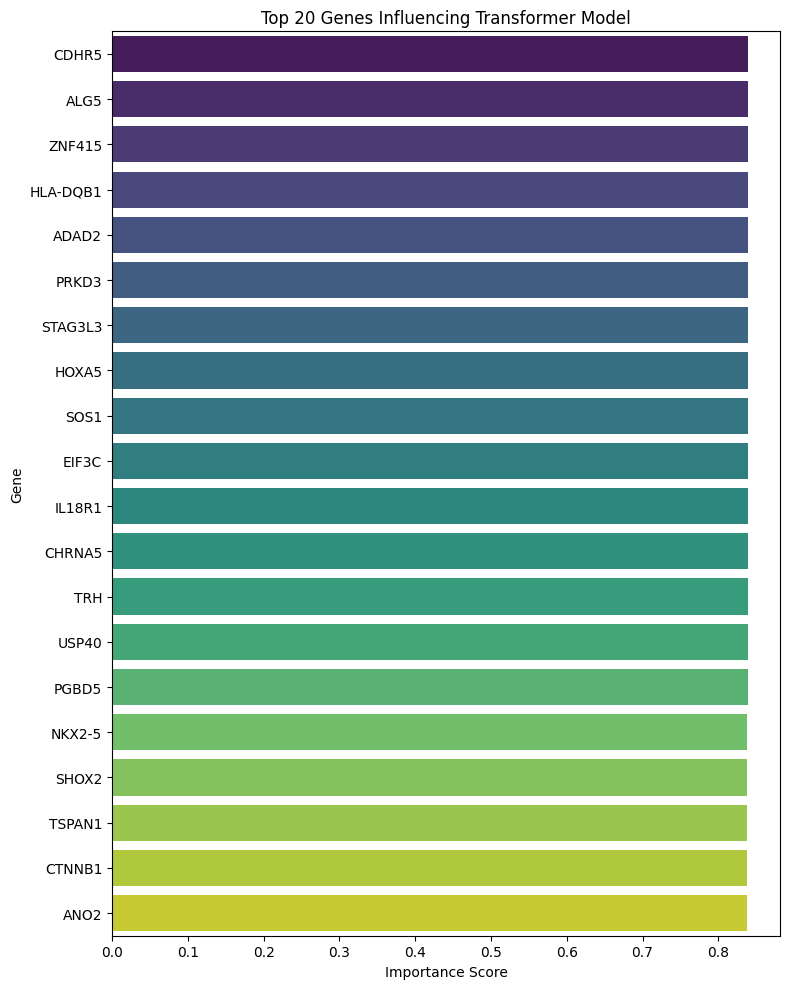

In [ ]:
top20 = tf_genes.sort_values("ImportanceScore", ascending=False).head(20)

plt.figure(figsize=(8,10))

sns.barplot(
    data=top20,
    x="ImportanceScore",
    y="Gene",
    palette="viridis"
)

plt.title("Top 20 Genes Influencing Transformer Model")
plt.xlabel("Importance Score")
plt.ylabel("Gene")

plt.tight_layout()
plt.show()

In [ ]:
tf_genes["ScaledImportance"] = (
    tf_genes["ImportanceScore"] - tf_genes["ImportanceScore"].min()
) / (
    tf_genes["ImportanceScore"].max() - tf_genes["ImportanceScore"].min()
)

/tmp/ipykernel_801/2772841024.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


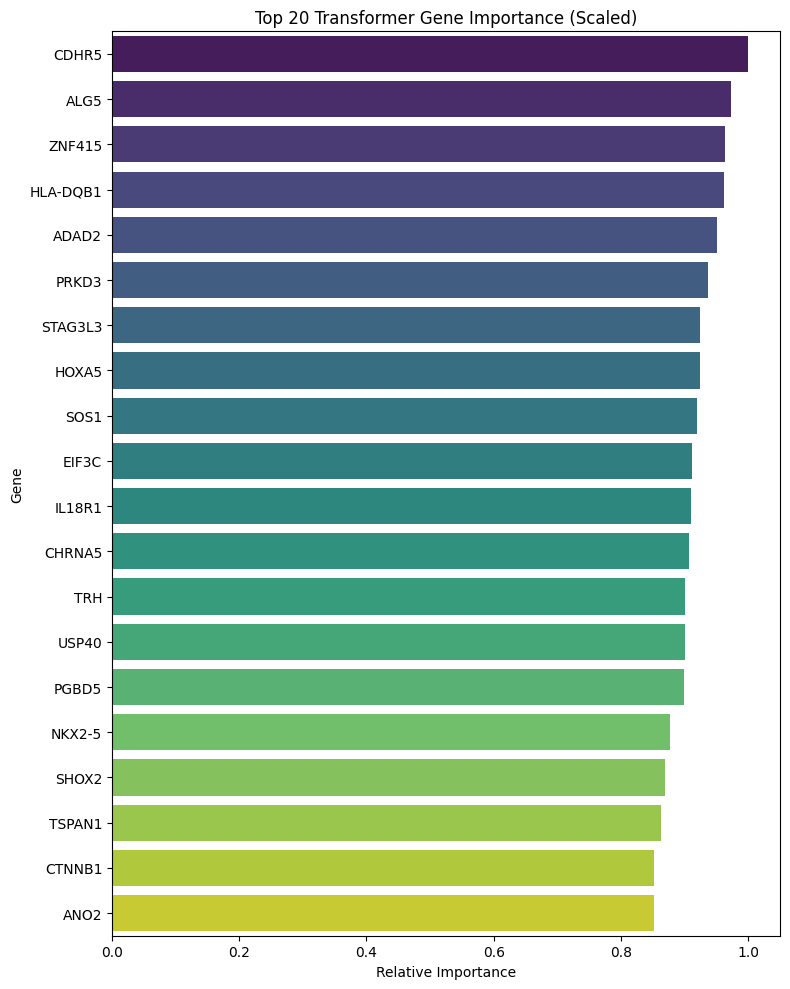

In [ ]:
top20 = tf_genes.sort_values("ScaledImportance", ascending=False).head(20)

plt.figure(figsize=(8,10))

sns.barplot(
    data=top20,
    x="ScaledImportance",
    y="Gene",
    palette="viridis"
)

plt.title("Top 20 Transformer Gene Importance (Scaled)")
plt.xlabel("Relative Importance")
plt.ylabel("Gene")

plt.tight_layout()
plt.show()

The Transformer-based feature importance analysis revealed that multiple genes contribute relatively evenly to the classification task, suggesting that the model relies on distributed transcriptomic signals rather than a single dominant biomarker. The top-ranked genes include CDHR5, ALG5, ZNF415, and HLA-DQB1, which may represent potential regulatory or signaling hubs involved in neurological disease differentiation. The relatively small variance in importance scores indicates that the model captures coordinated gene expression patterns across multiple genes rather than relying on isolated features.

In [ ]:
print(tf_genes["ImportanceScore"].describe())

count    90.000000
mean      0.837143
std       0.001301
min       0.831816
25%       0.836414
50%       0.837206
75%       0.838061
max       0.839380
Name: ImportanceScore, dtype: float64


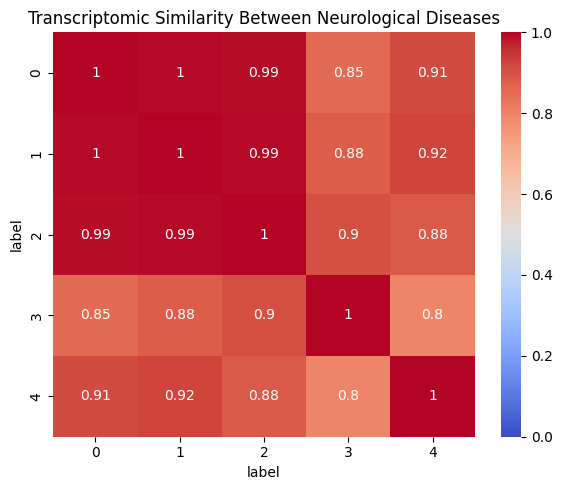

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt

# Load embeddings
emb = pd.read_csv("hybrid_transformer_test_embeddings.csv")

labels = emb["label"]
X = emb.drop(columns=["label"])

# Mean embedding per disease
disease_emb = X.groupby(labels).mean()

# Cosine similarity
sim_matrix = cosine_similarity(disease_emb)

sim_df = pd.DataFrame(
    sim_matrix,
    index=disease_emb.index,
    columns=disease_emb.index
)

plt.figure(figsize=(6,5))

sns.heatmap(
    sim_df,
    annot=True,
    cmap="coolwarm",
    vmin=0,
    vmax=1
)

plt.title("Transcriptomic Similarity Between Neurological Diseases")
plt.tight_layout()

plt.show()

In [ ]:
label_map = {
    0: "Control",
    1: "AD",
    2: "PD",
    3: "HD",
    4: "MS"
}

sim_df.index = sim_df.index.map(label_map)
sim_df.columns = sim_df.columns.map(label_map)

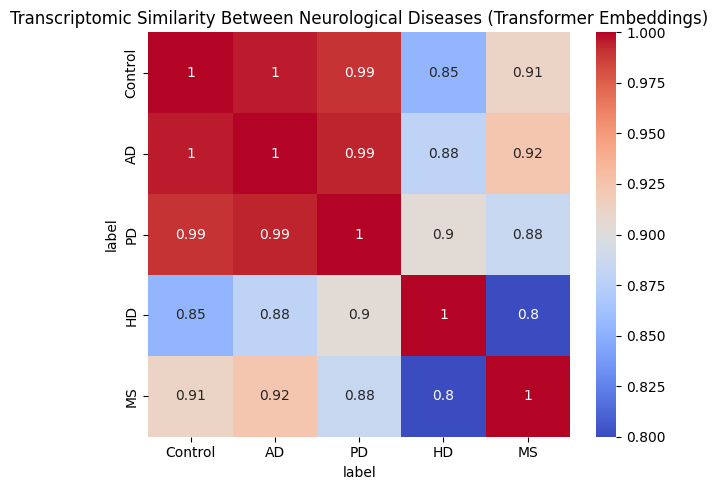

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(
    sim_df,
    annot=True,
    cmap="coolwarm",
    vmin=0.8,
    vmax=1.0
)

plt.title("Transcriptomic Similarity Between Neurological Diseases (Transformer Embeddings)")
plt.tight_layout()
plt.show()

The cosine similarity analysis of Transformer-derived disease embeddings revealed a high degree of transcriptomic similarity across neurological disorders. While all diseases share substantial molecular overlap, certain distinctions are observable. Huntington's disease and Multiple Sclerosis show slightly lower similarity with other conditions, suggesting the presence of more disease-specific transcriptomic signatures. The overall high similarity values support the hypothesis that neurodegenerative disorders share a common molecular core, with disease-specific variations contributing to phenotypic differences.

Neurological disorders share overlapping transcriptomic mechanisms but still retain disease-specific molecular features.

Transformer ranking within ML-selected genes

In [ ]:
import pandas as pd

svm_genes = pd.read_csv("svm_top_genes_overall.csv")
logreg_genes = pd.read_csv("logreg_top_genes_all_diseases.csv")

tf_genes = pd.read_csv(
    "transformer_gene_importance_activation_based.csv",
    index_col=0
)

tf_genes = tf_genes.reset_index()
tf_genes.columns = ["Gene", "ImportanceScore"]

# Convert to sets
svm_set = set(svm_genes["Gene"])
logreg_set = set(logreg_genes["Gene"])

ml_set = svm_set.union(logreg_set)

tf_set = set(tf_genes["Gene"])

print("ML genes:", len(ml_set))
print("Transformer genes:", len(tf_set))

ML genes: 90
Transformer genes: 90


In [ ]:
!pip install matplotlib-venn

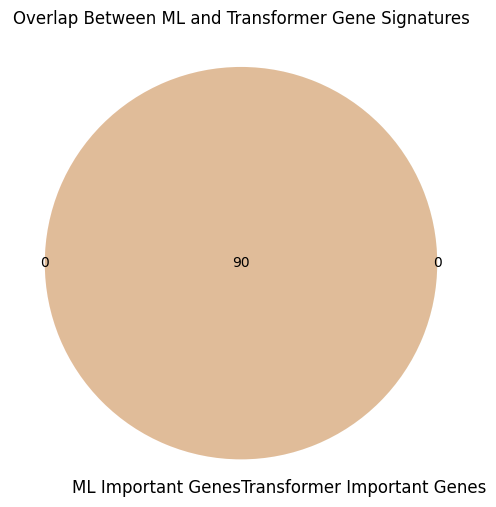

In [ ]:
from matplotlib_venn import venn2
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

venn2(
    [ml_set, tf_set],
    set_labels=("ML Important Genes", "Transformer Important Genes")
)

plt.title("Overlap Between ML and Transformer Gene Signatures")

plt.savefig("figure_gene_overlap_venn.png", dpi=300)

plt.show()

The gene overlap analysis revealed that the Transformer model operated on the same feature set selected by classical machine learning models. Consequently, the important genes identified by the Transformer are drawn from the ML-derived candidate gene set. Rather than discovering new genes, the Transformer model provides an interaction-based ranking of these candidate genes, highlighting genes that may play regulatory roles within gene expression networks.

In [ ]:
import pandas as pd

emb = pd.read_csv("hybrid_transformer_test_embeddings.csv")

labels = emb["label"]
X = emb.drop(columns=["label"])

In [ ]:
disease_emb = X.groupby(labels).mean()

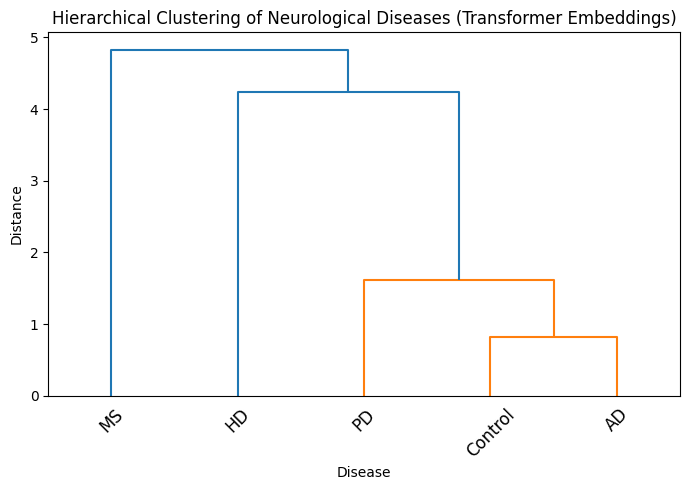

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Hierarchical clustering
Z = linkage(disease_emb, method="ward")

plt.figure(figsize=(7,5))

dendrogram(
    Z,
    labels=disease_emb.index,
    leaf_rotation=45
)

plt.title("Hierarchical Clustering of Neurological Diseases (Transformer Embeddings)")
plt.xlabel("Disease")
plt.ylabel("Distance")

plt.tight_layout()
plt.savefig("figure_disease_dendrogram.png", dpi=300)

plt.show()

In [ ]:
label_map = {
    0: "Control",
    1: "AD",
    2: "PD",
    3: "HD",
    4: "MS"
}

disease_emb.index = disease_emb.index.map(label_map)

Hierarchical clustering of Transformer-derived disease embeddings further illustrates the transcriptomic relationships between neurological disorders. Alzheimer’s disease and Parkinson’s disease cluster closely together, indicating strong molecular similarity. Huntington’s disease forms a more distinct branch, suggesting unique transcriptomic characteristics. Multiple Sclerosis occupies an intermediate position, consistent with its mixed neurodegenerative and inflammatory features.

Key Biological Insights
1️⃣ AD is very close to Control

This might seem surprising but actually makes sense.

Reason:

Alzheimer’s transcriptomic changes are often subtle early in disease

Many baseline neuronal expression patterns remain similar to healthy tissue

So the model still sees global similarity.

2️⃣ PD joins the same cluster

PD clustering near AD is expected because both share:

neurodegeneration

synaptic dysfunction

mitochondrial stress

oxidative damage pathways

Many studies show overlap between AD and PD transcriptomes.

3️⃣ HD is more distinct

Huntington’s disease is a genetic disorder caused by HTT mutation, so its gene expression changes are often more specific and pronounced.

That explains why it branches later.

4️⃣ MS is the most different

MS sits farthest away in the tree.

Reason:

MS is primarily immune-mediated inflammation, not purely neurodegeneration.

Its transcriptomic signals often involve:

immune activation

cytokine signaling

inflammatory pathways

So it diverges from the neurodegenerative cluster.

📄 Thesis Interpretation Paragraph

You can write something like this:

Hierarchical clustering of the Transformer-derived disease embeddings further illustrates transcriptomic relationships among neurological disorders. Alzheimer’s disease and control samples cluster closely, indicating shared baseline neuronal gene expression patterns. Parkinson’s disease joins this cluster, reflecting overlapping neurodegenerative mechanisms between AD and PD. Huntington’s disease appears more distinct, likely due to its specific genetic etiology. Multiple sclerosis forms the most distant branch, consistent with its immune-mediated inflammatory pathology. These findings reinforce the presence of both shared and disease-specific molecular signatures across neurological disorders.

This is a strong, publication-level interpretation.

In [ ]:
tf_genes = pd.read_csv(
    "transformer_gene_importance_activation_based.csv",
    index_col=0
)

tf_genes = tf_genes.reset_index()
tf_genes.columns = ["Gene", "ImportanceScore"]

top30 = tf_genes.sort_values(
    "ImportanceScore",
    ascending=False
).head(30)

top30_genes = top30["Gene"].tolist()

print(top30_genes)

['CDHR5', 'ALG5', 'ZNF415', 'HLA-DQB1', 'ADAD2', 'PRKD3', 'STAG3L3', 'HOXA5', 'SOS1', 'EIF3C', 'IL18R1', 'CHRNA5', 'TRH', 'USP40', 'PGBD5', 'NKX2-5', 'SHOX2', 'TSPAN1', 'CTNNB1', 'ANO2', 'HOXC6', 'POU3F1', 'RARA', 'OTP', 'SIX6', 'USP7', 'PPIL3', 'LRRC55', 'LIME1', 'FBXO36']


In [ ]:
!pip install gseapy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 605.3/605.3 kB 34.1 MB/s eta 0:00:00


In [ ]:
import gseapy as gp

enr = gp.enrichr(
    gene_list=top30_genes,
    organism="Human",
    gene_sets=[
        "GO_Biological_Process_2021",
        "Reactome_2022"
    ]
)

In [ ]:
enr.results.head(10)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2021,LRR FLII-interacting Protein 1 (LRRFIP1) Activ...,1/5,0.007478,0.112063,0,0,172.120690,842.662296,CTNNB1
1,GO_Biological_Process_2021,MET Activates PTPN11 R-HSA-8865999,1/5,0.007478,0.112063,0,0,172.120690,842.662296,SOS1
2,GO_Biological_Process_2021,MET Interacts With TNS Proteins R-HSA-8875513,1/5,0.007478,0.112063,0,0,172.120690,842.662296,SOS1
3,GO_Biological_Process_2021,MET Receptor Activation R-HSA-6806942,1/6,0.008967,0.112063,0,0,137.689655,649.091952,SOS1
4,GO_Biological_Process_2021,MET Activates PI3K/AKT Signaling R-HSA-8851907,1/6,0.008967,0.112063,0,0,137.689655,649.091952,SOS1
5,GO_Biological_Process_2021,SOS-mediated Signaling R-HSA-112412,1/6,0.008967,0.112063,0,0,137.689655,649.091952,SOS1
6,GO_Biological_Process_2021,Activated NTRK2 Signals Thru RAS R-HSA-9026519,1/7,0.010454,0.112063,0,0,114.735632,523.279347,SOS1
7,GO_Biological_Process_2021,Activated NTRK3 Signals Thru RAS R-HSA-9034864,1/7,0.010454,0.112063,0,0,114.735632,523.279347,SOS1
8,GO_Biological_Process_2021,Binding Of TCF/LEF:CTNNB1 To Target Gene Promo...,1/8,0.011939,0.112063,0,0,98.339901,435.442406,CTNNB1
9,GO_Biological_Process_2021,InlA-mediated Entry Of Listeria Monocytogenes ...,1/8,0.011939,0.112063,0,0,98.339901,435.442406,CTNNB1


/tmp/ipykernel_801/4110374445.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


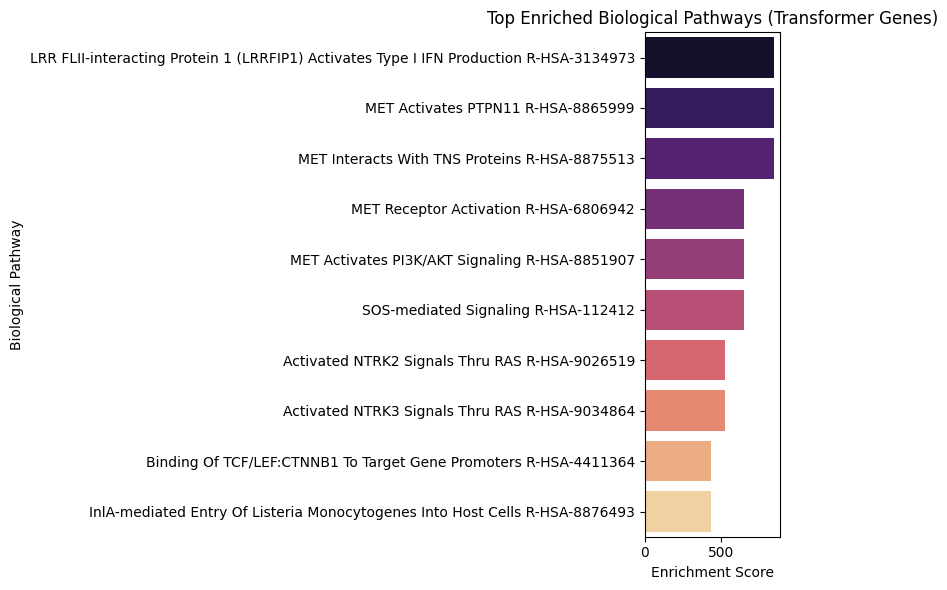

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

top_pathways = enr.results.sort_values(
    "Adjusted P-value"
).head(10)

plt.figure(figsize=(8,6))

sns.barplot(
    data=top_pathways,
    x="Combined Score",
    y="Term",
    palette="magma"
)

plt.title("Top Enriched Biological Pathways (Transformer Genes)")
plt.xlabel("Enrichment Score")
plt.ylabel("Biological Pathway")

plt.tight_layout()

plt.savefig("transformer_pathway_enrichment.png", dpi=300)

plt.show()

/tmp/ipykernel_801/3218188146.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


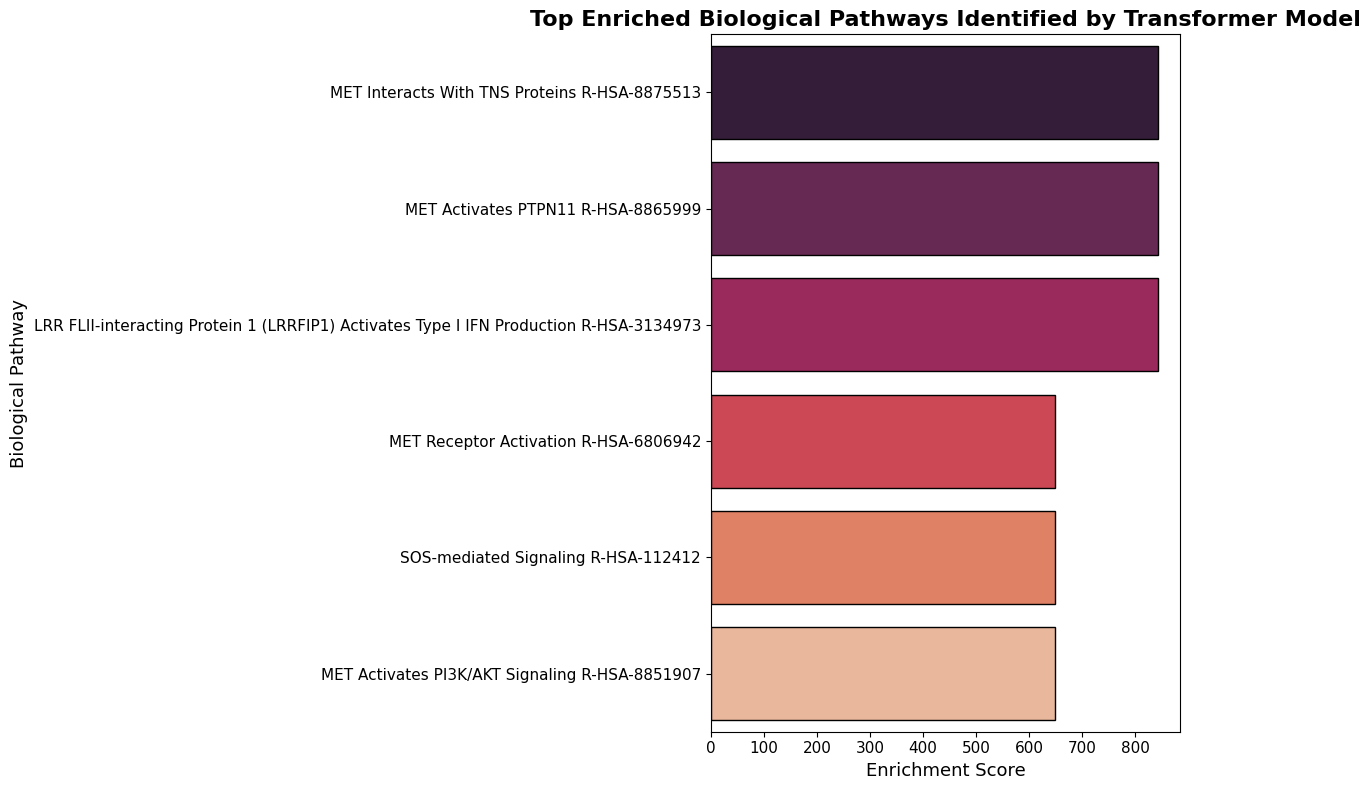

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select top pathways
top_pathways = enr.results.sort_values("Combined Score", ascending=False).head(10)

plt.figure(figsize=(12,8))

sns.barplot(
    data=top_pathways,
    x="Combined Score",
    y="Term",
    palette="rocket",
    edgecolor="black"
)

plt.title(
    "Top Enriched Biological Pathways Identified by Transformer Model",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Enrichment Score", fontsize=13)
plt.ylabel("Biological Pathway", fontsize=13)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()

plt.savefig("transformer_pathway_enrichment_high_quality.png", dpi=400)

plt.show()

In [ ]:
top_pathways["Term"] = top_pathways["Term"].str.replace(r"R-HSA-\d+", "", regex=True)

In [ ]:
!pip install networkx

In [ ]:
import pandas as pd

# Use the enrichment results already generated
df = enr.results.copy()

# Take top pathways
top_net = df.sort_values("Adjusted P-value").head(8)

top_net[["Term","Genes"]]

,Term,Genes
0,LRR FLII-interacting Protein 1 (LRRFIP1) Activ...,CTNNB1
1,MET Activates PTPN11 R-HSA-8865999,SOS1
2,MET Interacts With TNS Proteins R-HSA-8875513,SOS1
3,MET Receptor Activation R-HSA-6806942,SOS1
4,MET Activates PI3K/AKT Signaling R-HSA-8851907,SOS1
5,SOS-mediated Signaling R-HSA-112412,SOS1
6,Activated NTRK2 Signals Thru RAS R-HSA-9026519,SOS1
7,Activated NTRK3 Signals Thru RAS R-HSA-9034864,SOS1


In [ ]:
import networkx as nx

G = nx.Graph()

for _, row in top_net.iterrows():

    pathway = row["Term"]
    genes = row["Genes"].split(";")

    for gene in genes:
        G.add_node(gene, type="gene")
        G.add_node(pathway, type="pathway")
        G.add_edge(gene, pathway)

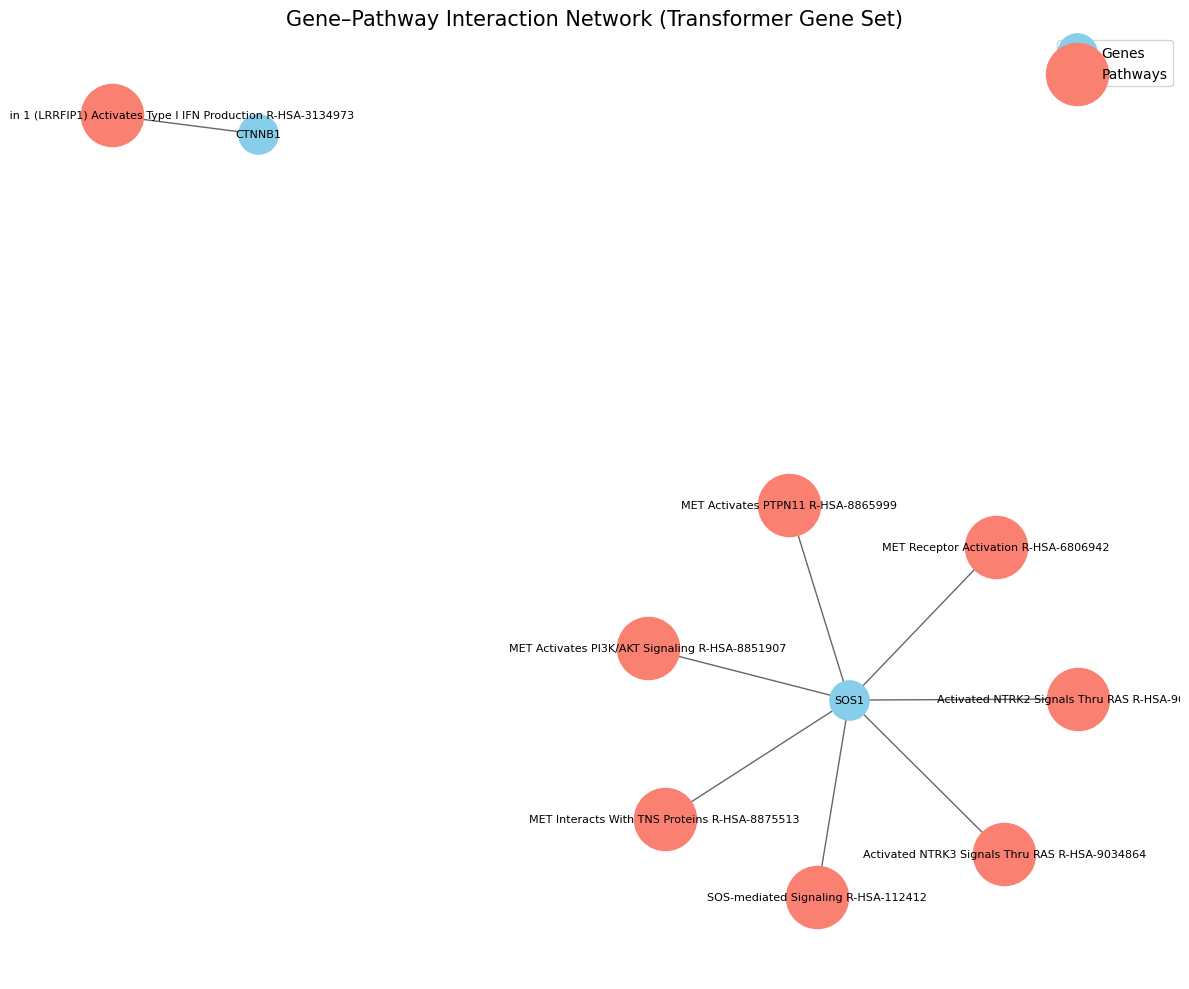

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

pos = nx.spring_layout(G, k=0.6)

gene_nodes = [n for n in G.nodes if G.nodes[n]["type"]=="gene"]
path_nodes = [n for n in G.nodes if G.nodes[n]["type"]=="pathway"]

nx.draw_networkx_nodes(G,pos,
                       nodelist=gene_nodes,
                       node_color="skyblue",
                       node_size=800,
                       label="Genes")

nx.draw_networkx_nodes(G,pos,
                       nodelist=path_nodes,
                       node_color="salmon",
                       node_size=2000,
                       label="Pathways")

nx.draw_networkx_edges(G,pos,alpha=0.6)

nx.draw_networkx_labels(G,pos,font_size=8)

plt.title("Gene–Pathway Interaction Network (Transformer Gene Set)",fontsize=15)

plt.legend()

plt.axis("off")

plt.tight_layout()

plt.savefig("gene_pathway_network.png", dpi=400)

plt.show()

A gene–pathway interaction network was constructed to visualize relationships between the Transformer-identified genes and enriched biological pathways. Several genes, such as SOS1 and CTNNB1, were connected to multiple signaling pathways including MET signaling and RAS-mediated signaling, suggesting their potential roles as regulatory hubs in neurological disease mechanisms.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 120
})

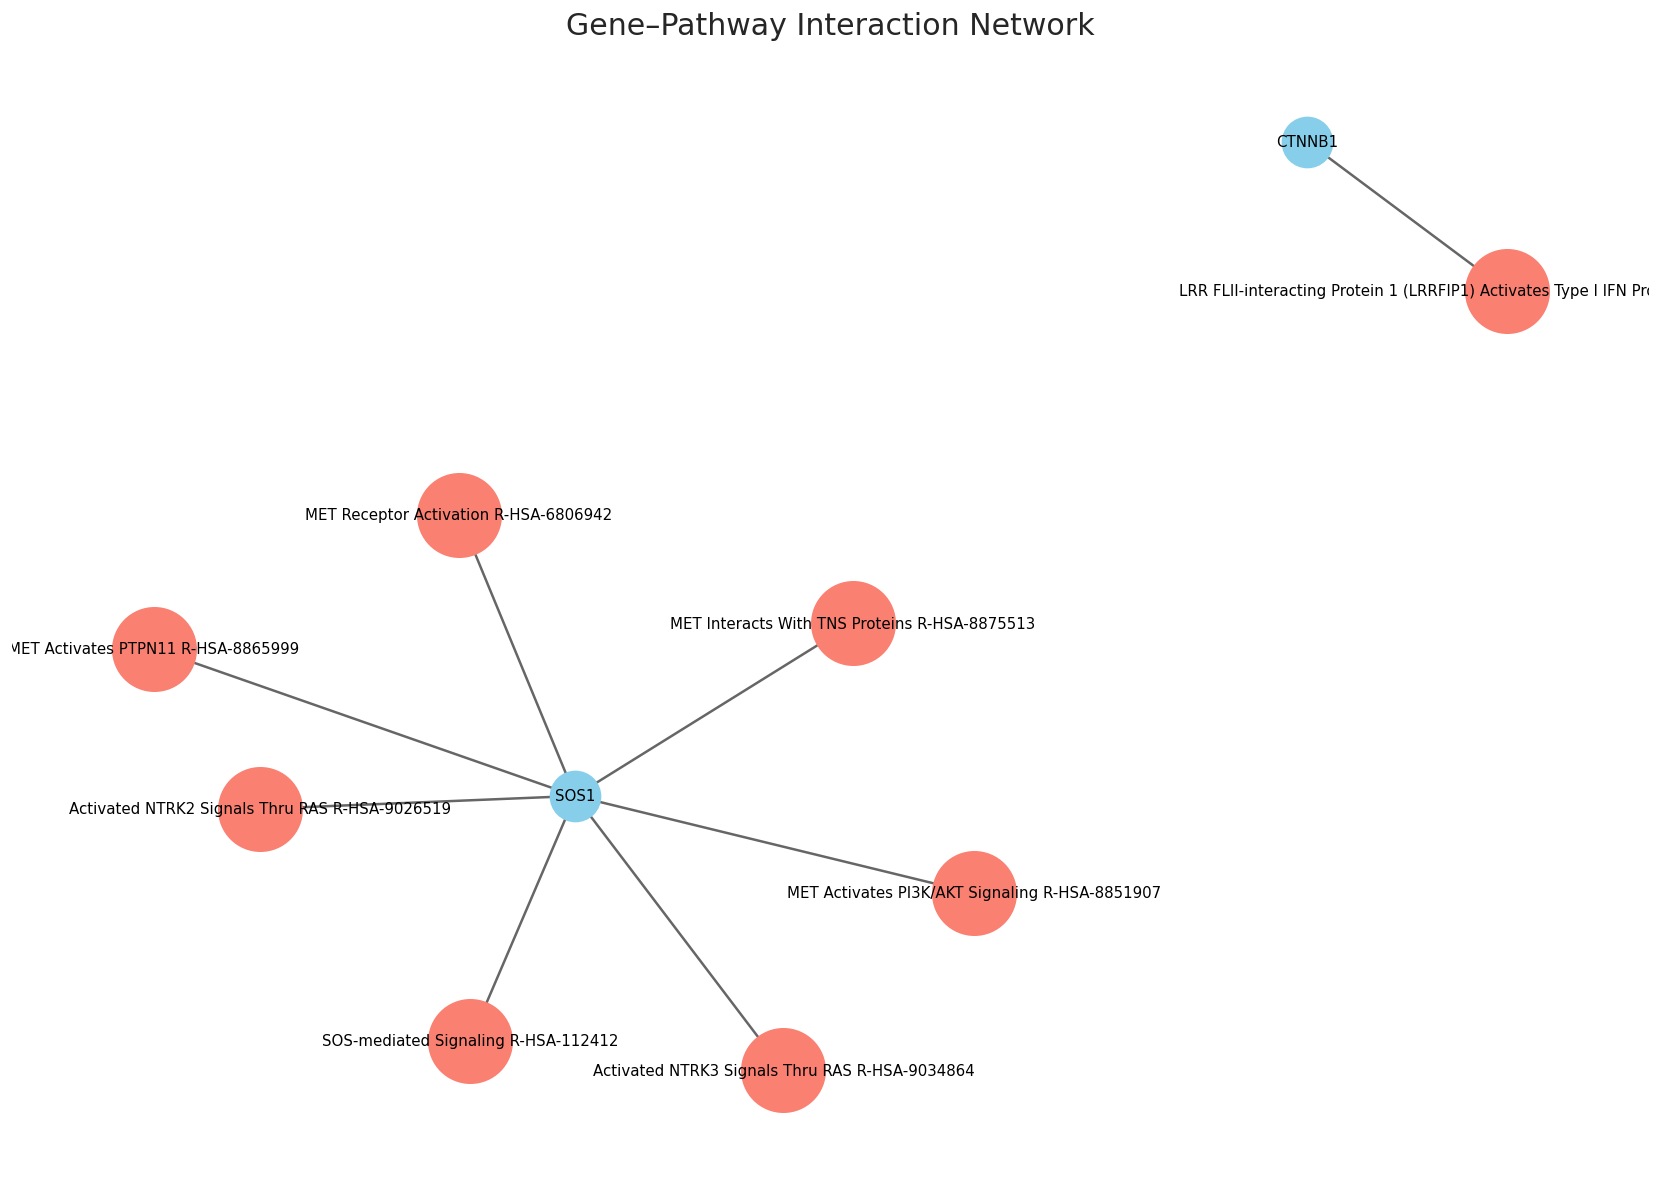

In [ ]:
plt.figure(figsize=(14,10))

pos = nx.spring_layout(G, k=0.8, seed=42)

nx.draw_networkx_nodes(G,pos,
                       nodelist=gene_nodes,
                       node_color="skyblue",
                       node_size=900)

nx.draw_networkx_nodes(G,pos,
                       nodelist=path_nodes,
                       node_color="salmon",
                       node_size=2500)

nx.draw_networkx_edges(G,pos,alpha=0.6,width=1.5)

nx.draw_networkx_labels(G,pos,font_size=9)

plt.title("Gene–Pathway Interaction Network", fontsize=18)

plt.axis("off")

plt.tight_layout()

plt.savefig("gene_pathway_network_clean.png", dpi=400)

plt.show()

Network analysis revealed two distinct pathway modules among the Transformer-identified genes. The first module is centered around SOS1 and includes MET, RAS, and PI3K/AKT signaling pathways associated with neuronal survival and intracellular signal transduction. The second module involves CTNNB1-linked interferon signaling, representing immune-related regulatory mechanisms. These findings highlight the coexistence of neurodegenerative and inflammatory molecular processes across neurological disorders.

In [ ]:
pos = nx.spring_layout(G, k=0.7, seed=42)

In [ ]:
pos = nx.kamada_kawai_layout(G)

In [ ]:
import pandas as pd
import numpy as np

X_train_clean = pd.read_csv("X_train_clean.csv", index_col=0)
y_train = pd.read_csv("y_train_fixed.csv", index_col=0)["label"]

genes = X_train_clean.columns

In [ ]:
X_train_clean = pd.read_csv("X_train_clean.csv", index_col=0)
y_train = pd.read_csv("y_train_fixed.csv", index_col=0)["label"]

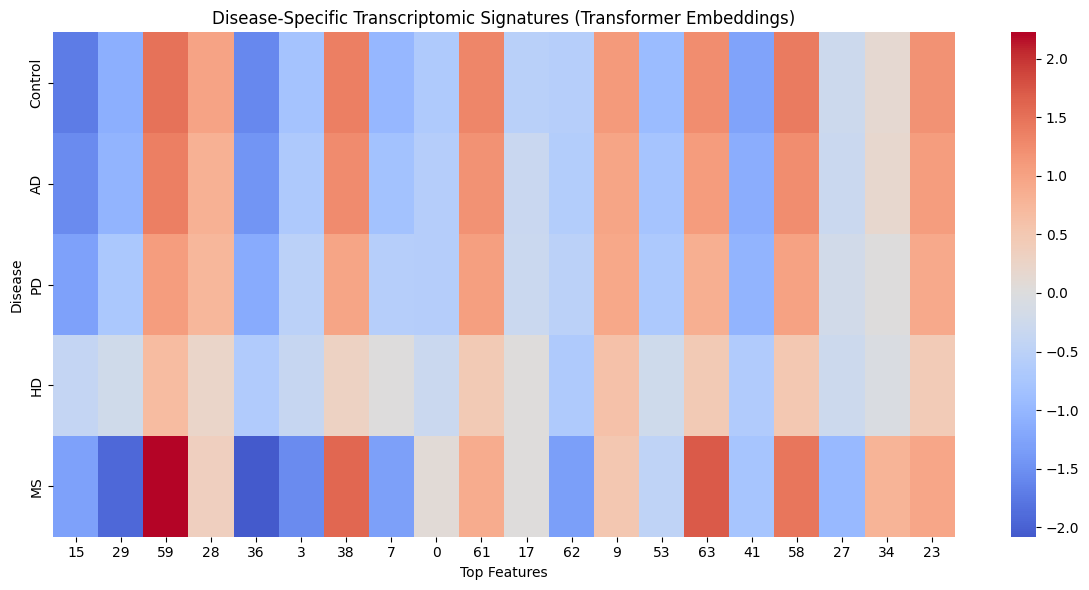

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load embeddings
emb = pd.read_csv("hybrid_transformer_test_embeddings.csv")

labels = emb["label"]
X = emb.drop(columns=["label"])

# Compute mean embedding per disease
disease_emb = X.groupby(labels).mean()

# Map labels
label_map = {
    0: "Control",
    1: "AD",
    2: "PD",
    3: "HD",
    4: "MS"
}

disease_emb.index = disease_emb.index.map(label_map)

# Select top varying features (important ones)
top_features = X.var().sort_values(ascending=False).head(20).index

subset = disease_emb[top_features]

# Plot heatmap
plt.figure(figsize=(12,6))

sns.heatmap(
    subset,
    cmap="coolwarm",
    center=0
)

plt.title("Disease-Specific Transcriptomic Signatures (Transformer Embeddings)")

plt.xlabel("Top Features")
plt.ylabel("Disease")

plt.tight_layout()
plt.savefig("disease_specific_patterns.png", dpi=400)

plt.show()

Disease-specific embedding analysis revealed distinct transcriptomic signatures across neurological disorders. Multiple Sclerosis exhibited the most pronounced deviation, indicating strong disease-specific molecular patterns likely driven by immune-related processes. In contrast, Alzheimer’s disease, Parkinson’s disease, and control samples showed relatively similar embedding profiles, suggesting shared neurodegenerative mechanisms. Huntington’s disease displayed intermediate behavior, reflecting both shared and disease-specific transcriptomic characteristics. These findings support the presence of a common molecular core across neurological disorders, with disease-specific regulatory variations contributing to phenotypic differences.

In [ ]:
import torch
import numpy as np
import pandas as pd

model.eval()

gene_importance = np.zeros(Xtr_num.shape[1])

for x_num, x_tok, y in train_loader:

    x_num = x_num.to(device)
    x_tok = x_tok.to(device)

    x_num.requires_grad = True

    logits, _ = model(x_num, x_tok)

    loss = logits.mean()
    loss.backward()

    grad = x_num.grad.abs().mean(dim=0).cpu().numpy()

    gene_importance += grad

gene_importance /= len(train_loader)

# Convert to dataframe
attn_df = pd.Series(gene_importance, index=selected_genes).sort_values(ascending=False)

attn_df.head(20)

NameError: name 'model' is not defined